# Dengue Cases and Deaths in the Philippines (2016-2020)
This workbook performs spatiotemporal analysis on dengue data to identify trends
and regional hotspots.

In [28]:
#Import Dependencies/Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [29]:
#Connect your Google Drive

In [30]:
#Upload your dataset
df = pd.read_csv('ph_dengue_cases2016-2020.csv')

### Data Cleaning
#### Plan:
- Inspect structure, data types, null values and duplicates
- Add ``Month_Num`` for chronological sorting of months
- Validate value ranges

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Month          1020 non-null   object
 1   Year           1020 non-null   int64 
 2   Region         1020 non-null   object
 3   Dengue_Cases   1020 non-null   int64 
 4   Dengue_Deaths  1020 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 40.0+ KB


In [32]:
# Inspect structure, data types, null values and duplicates
print('DATA TYPES')
print(df.dtypes)
print()
print('NULL VALUES')
print(df.isnull().sum())
print()
print('DUPLICATES')
print('Duplicate rows:', df.duplicated().sum())

DATA TYPES
Month            object
Year              int64
Region           object
Dengue_Cases      int64
Dengue_Deaths     int64
dtype: object

NULL VALUES
Month            0
Year             0
Region           0
Dengue_Cases     0
Dengue_Deaths    0
dtype: int64

DUPLICATES
Duplicate rows: 0


In [33]:
df.describe()

,Year,Dengue_Cases,Dengue_Deaths
count,1020.000000,1020.000000,1020.000000
mean,2018.000000,1124.926471,16.513725
std,1.414907,1662.608878,96.358215
min,2016.000000,10.000000,0.000000
25%,2017.000000,247.750000,1.000000
50%,2018.000000,582.500000,3.000000
75%,2019.000000,1284.250000,7.000000
max,2020.000000,21658.000000,1651.000000


In [34]:
# Add Month_Num for proper chronological ordering
month_order = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6, 'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}

df['Month_Num'] = df['Month'].map(month_order)

In [35]:
# Validate range values
print('VALUE RANGES')
print(f'Years: {sorted(df['Year'].unique())}')
print(f'Months: {df['Month_Num'].min()} to {df['Month_Num'].max()} ({df['Month_Num'].nunique()} months)')
print(f'Regions: {df['Region'].nunique()} unique regions')
print(f'Cases range: {df['Dengue_Cases'].min()} - {df['Dengue_Cases'].max()}')
print(f'Deaths range: {df['Dengue_Deaths'].min()} - {df['Dengue_Deaths'].max()}')

#Check for negative values
neg_cases = (df['Dengue_Cases'] < 0).sum()
neg_deaths = (df['Dengue_Deaths'] < 0).sum()
print(f'''
Negative cases: {neg_cases}
Negative deaths: {neg_deaths}''')

VALUE RANGES
Years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
Months: 1 to 12 (12 months)
Regions: 17 unique regions
Cases range: 10 - 21658
Deaths range: 0 - 1651

Negative cases: 0
Negative deaths: 0


#### **The dataset is clean and ready for analysis.**
- No null values
- No duplicate rows
- No negative values
- Data types are matched to values
- ``Month_Num`` column added for chronological sorting.

## Exploratory Data Analysis
1. Cases per year
2. Cases per month
3. Cases per region
4. Heatmap: region x year
5. Scatter: cases x deaths

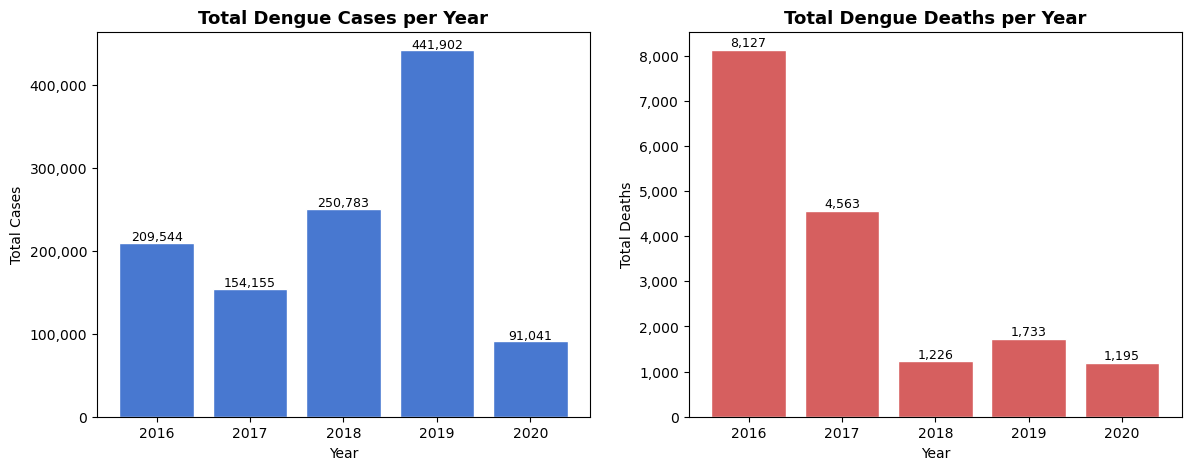

In [36]:
# 1. Cases per year
annual = df.groupby('Year')[['Dengue_Cases', 'Dengue_Deaths']].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(annual['Year'], annual['Dengue_Cases'], color=sns.color_palette('muted')[0], edgecolor='white')
axes[0].set_title('Total Dengue Cases per Year', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Cases')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _:f'{x:,.0f}'))   # adds comma for numbers
for i, (year, val) in enumerate(zip(annual['Year'], annual['Dengue_Cases'])):            # places values on top of bars
    axes[0].text(year, val + 2500, f'{val:,}', ha='center', fontsize=9)

axes[1].bar(annual['Year'], annual['Dengue_Deaths'], color=sns.color_palette('muted')[3], edgecolor='white')
axes[1].set_title('Total Dengue Deaths per Year', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Deaths')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _:f'{x:,.0f}'))
for i, (year, val) in enumerate(zip(annual['Year'], annual['Dengue_Deaths'])):
    axes[1].text(year, val + 75, f'{val:,}', ha='center', fontsize=9)


plt.show()

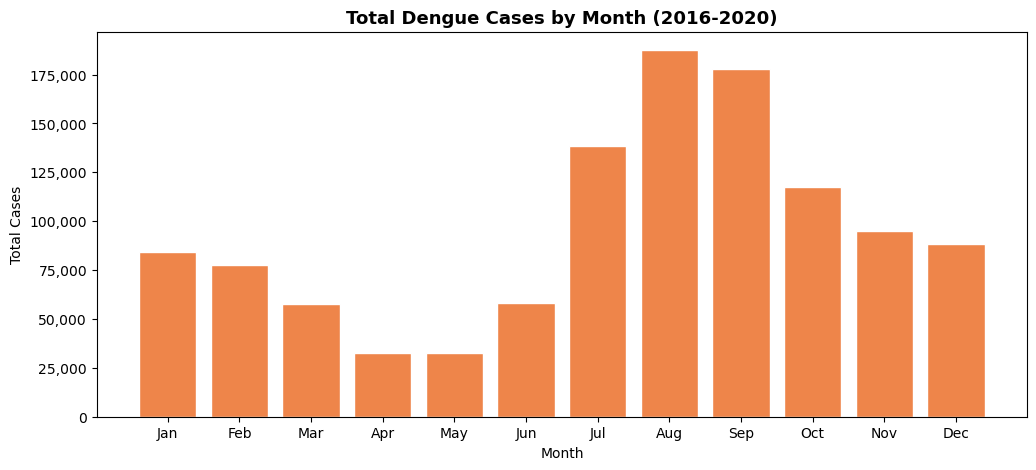

In [37]:
# 2. Cases per month (all years aggregated)
monthly = df.groupby('Month_Num')['Dengue_Cases'].sum().reset_index()
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly['Month_Num'], monthly['Dengue_Cases'], color=sns.color_palette('muted')[1], edgecolor='white')
ax.set_xticks(range(1,13))
ax.set_xticklabels(month_labels)
ax.set_title('Total Dengue Cases by Month (2016-2020)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Total Cases')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _:f'{x:,.0f}'))

plt.show()

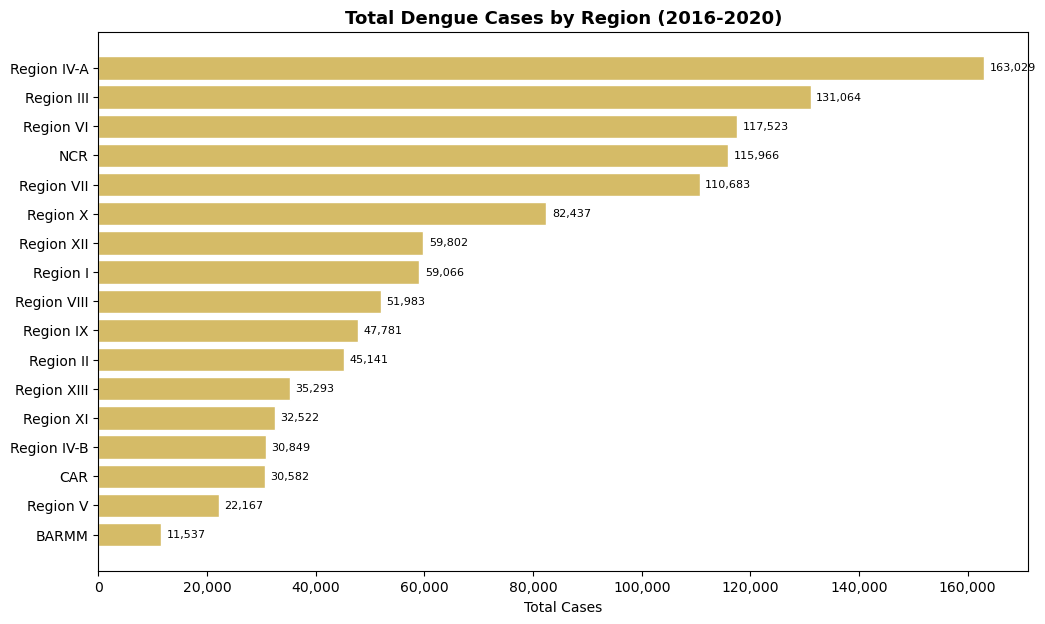

In [38]:
# 3. Cases per Region
regional = df.groupby('Region')['Dengue_Cases'].sum().sort_values(ascending=True).reset_index()

fig, ax = plt.subplots(figsize= (12, 7))
bars = ax.barh(regional['Region'], regional['Dengue_Cases'], color=sns.color_palette('muted')[8], edgecolor='white')
ax.set_title('Total Dengue Cases by Region (2016-2020)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Cases')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _:f'{x:,.0f}'))
for bar, val in zip(bars, regional['Dengue_Cases']):
    ax.text(val + 1000, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=8)

plt.show()

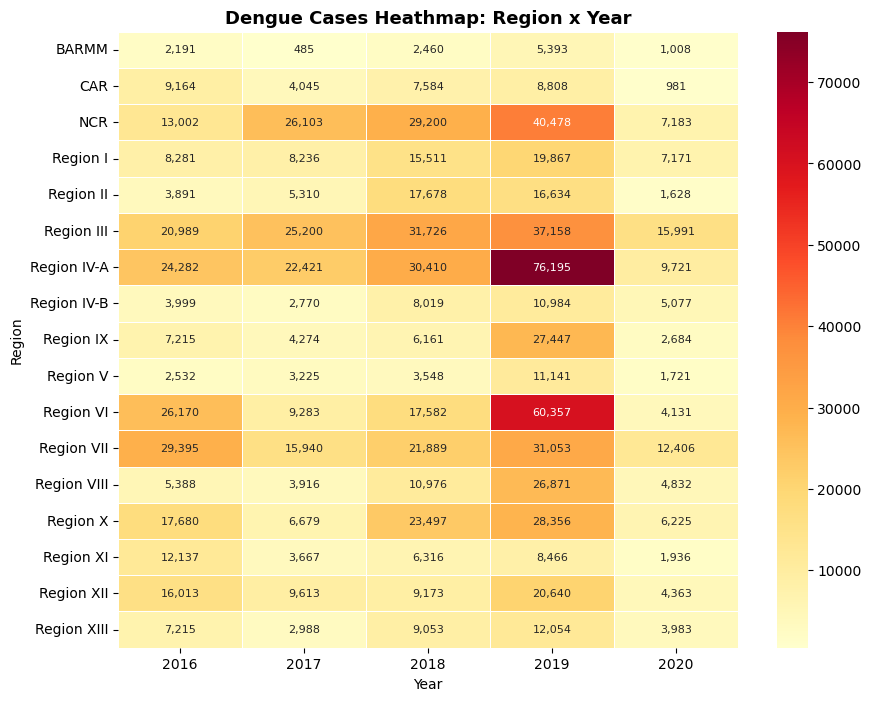

In [39]:
# Heatmap: Cases by Region and Year
pivot_region_year = df.groupby(['Region', 'Year'])['Dengue_Cases'].sum().unstack()
# pivot_region_year

fig, ax = plt.subplots(figsize= (10, 8))
sns.heatmap(pivot_region_year, annot=True, fmt=',d', cmap='YlOrRd', linewidths=0.5, ax = ax, annot_kws={'size': 8})
ax.set_title('Dengue Cases Heathmap: Region x Year', fontsize=13, fontweight='bold')
plt.show()

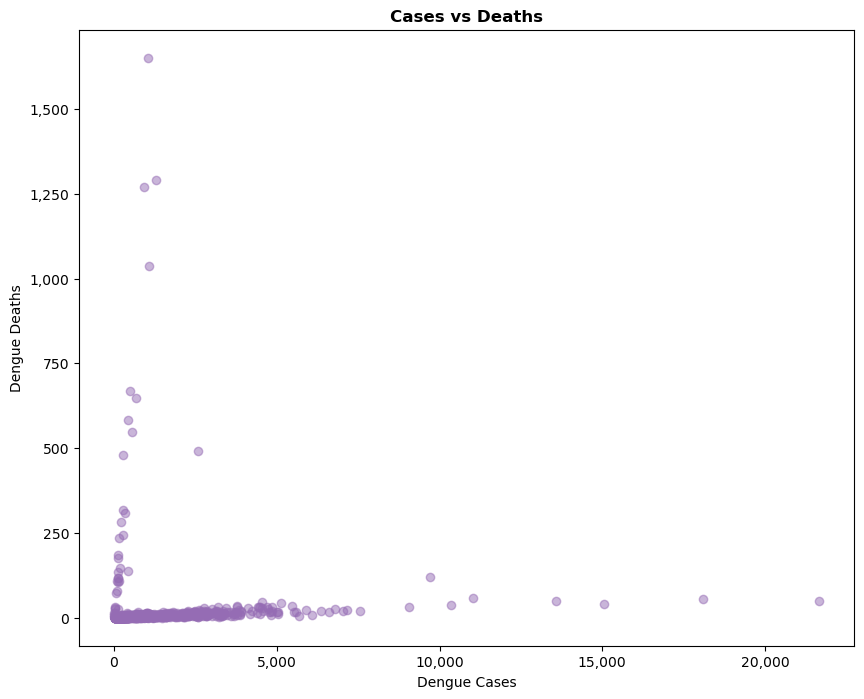

In [40]:
x = df['Dengue_Cases']
y = df['Dengue_Deaths']

fig, ax = plt.subplots(figsize= (10, 8))
ax.scatter(x, y, color = sns.color_palette('muted')[4], alpha = 0.5)
ax.set_title('Cases vs Deaths', fontsize=12, fontweight='bold')
ax.set_xlabel('Dengue Cases')
ax.set_ylabel('Dengue Deaths')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _:f'{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _:f'{x:,.0f}'))

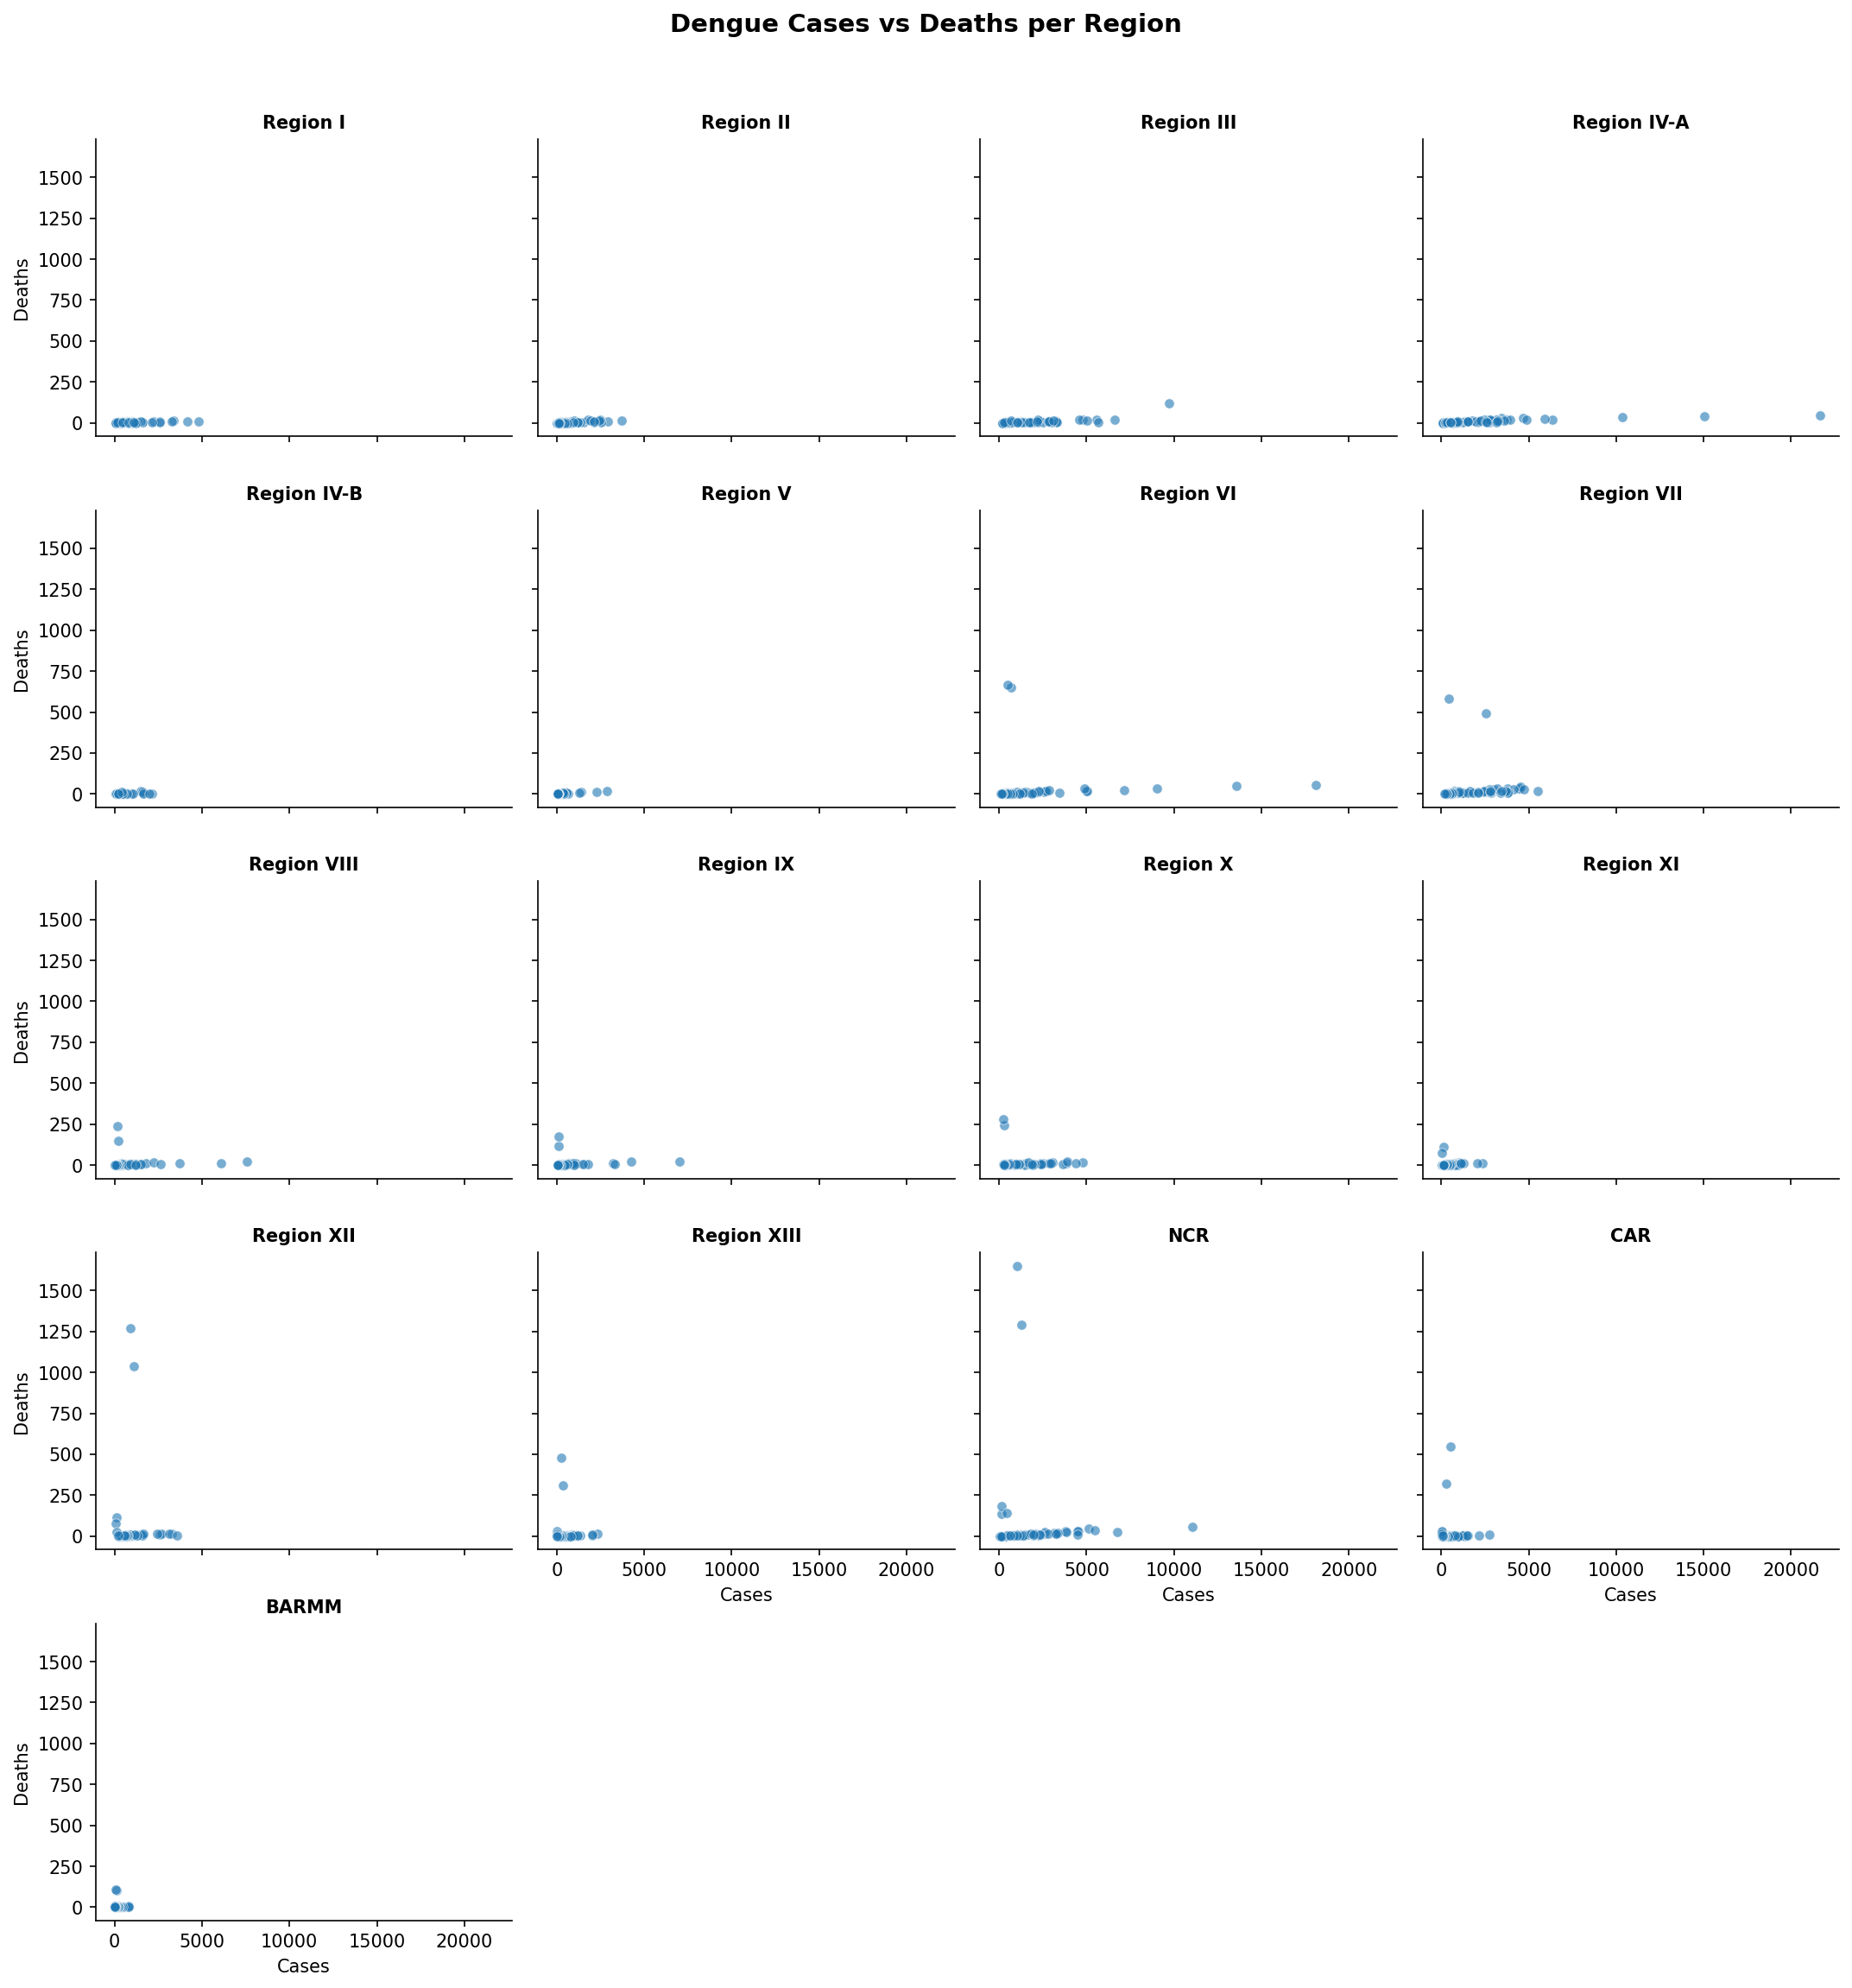

In [41]:
g = sns.FacetGrid(df, col='Region', col_wrap=4, height=3, aspect=1.2)
g.map(sns.scatterplot, 'Dengue_Cases', 'Dengue_Deaths', alpha=0.6, s=30)
g.set_axis_labels('Cases', 'Deaths')
g.set_titles(col_template='{col_name}', fontweight='bold')
g.figure.suptitle('Dengue Cases vs Deaths per Region', fontsize=14, fontweight='bold', y=1.02)
g.figure.set_dpi(150)
plt.tight_layout()
plt.show()

### Answering the key Questions
#### Q1. Which months represent peak Dengue Season, and was 2019 significantly higher?
July to October represent peak Dengue Season, with August having the highest number of cases across all years. 2019 was significantly higher than any other year. With 441, 902 total cases, it has nearly twice of 2018's and almost five times of 2020's.

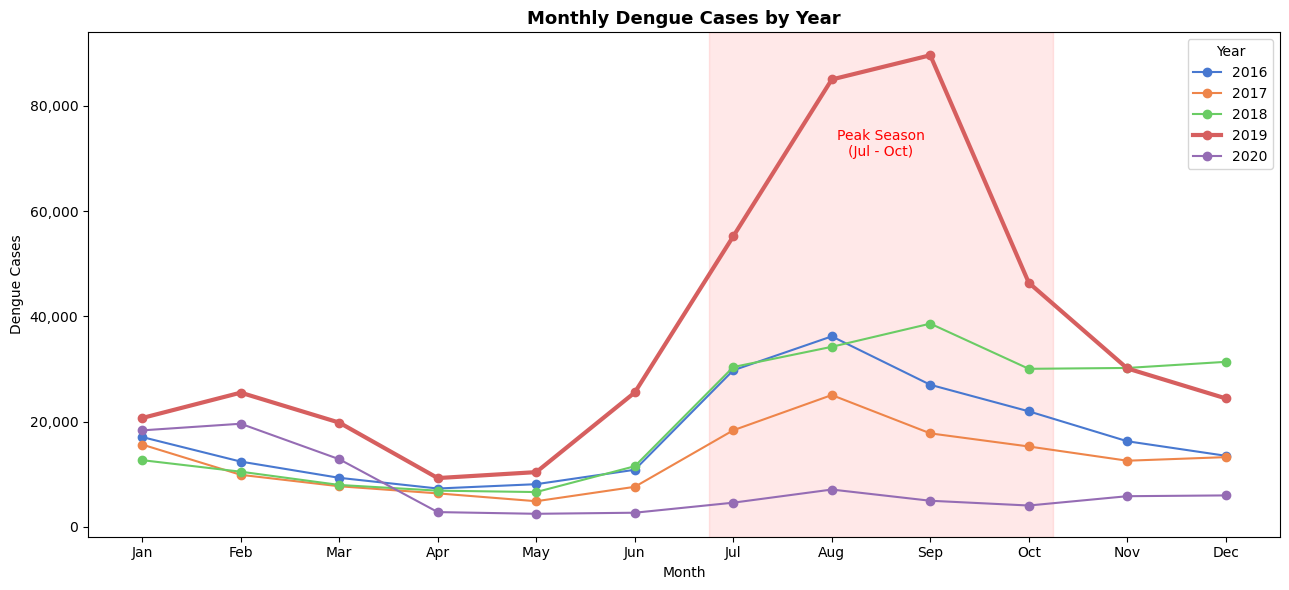

In [42]:
monthly_by_year = df.groupby(['Year', 'Month_Num'])['Dengue_Cases'].sum().reset_index()
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fix, ax = plt.subplots(figsize=(13, 6))
colors = sns.color_palette('muted', 5)
for i, year in enumerate(sorted(monthly_by_year['Year'].unique())):
    subset = monthly_by_year[monthly_by_year['Year'] == year].sort_values('Month_Num')
    lw = 3 if year == 2019 else 1.5
    ax.plot(subset['Month_Num'], subset['Dengue_Cases'], marker='o', label=str(year), color=colors[i], linewidth=lw, linestyle='-')

ax.set_xticks(range(1,13))
ax.set_xticklabels(month_labels)
ax.set_title('Monthly Dengue Cases by Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Dengue Cases')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _:f'{x:,.0f}'))
ax.legend(title = 'Year')
ax.axvspan(6.75, 10.25, alpha=0.09, color='red', label='Peak season')   # highlights
ax.text(8.5, ax.get_ylim()[1]*0.75, 'Peak Season\n(Jul - Oct)', ha='center', fontsize=10, color='red')
plt.tight_layout()
plt.show()

In [43]:
# 2019 vs other years
print('ANNUAL DENGUE CASES')
for yr, cases in df.groupby('Year'):
    total = cases['Dengue_Cases'].sum()
    print(f'{yr}: {total:,} cases')

ANNUAL DENGUE CASES
2016: 209,544 cases
2017: 154,155 cases
2018: 250,783 cases
2019: 441,902 cases
2020: 91,041 cases


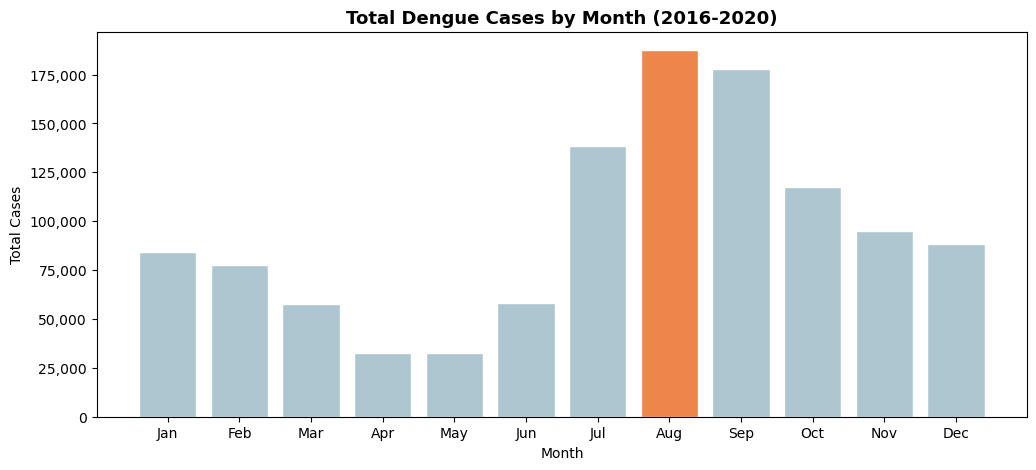

Aug has the highest case across all years.


In [44]:
monthly = df.groupby('Month_Num')['Dengue_Cases'].sum().reset_index()
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
colors_bar = [sns.color_palette('muted')[1] if m == 8 else '#aec6cf'
              for i, m in enumerate(monthly['Month_Num'])]
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly['Month_Num'], monthly['Dengue_Cases'], color=colors_bar, edgecolor='white')
ax.set_xticks(range(1,13))
ax.set_xticklabels(month_labels)
ax.set_title('Total Dengue Cases by Month (2016-2020)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Total Cases')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _:f'{x:,.0f}'))

plt.show()

highest = monthly['Month_Num'][monthly['Dengue_Cases'].idxmax()]
print(f'{month_labels[highest-1]} has the highest case across all years.')

#### Q2. Top 3 regions with highest cases, and how does Region IV-A compare to NCR?
The three regions with the highest cummulative cases are
| Region       | Dengue Cases |
| ------------ | ------------ |
| Region IV- A | 163,029      |
| Region III   | 131,064      |
| Region VI    | 117,523      |

Region IV-A recorded 1.4x more cases than NCR despite NCR being the most densely populated area. However, when looking at deaths, the ranking changes. NCR, with 4,008 total deaths, is the region with the most deaths, while Region IV-A ranks only 8th in deaths despite having the most cases.

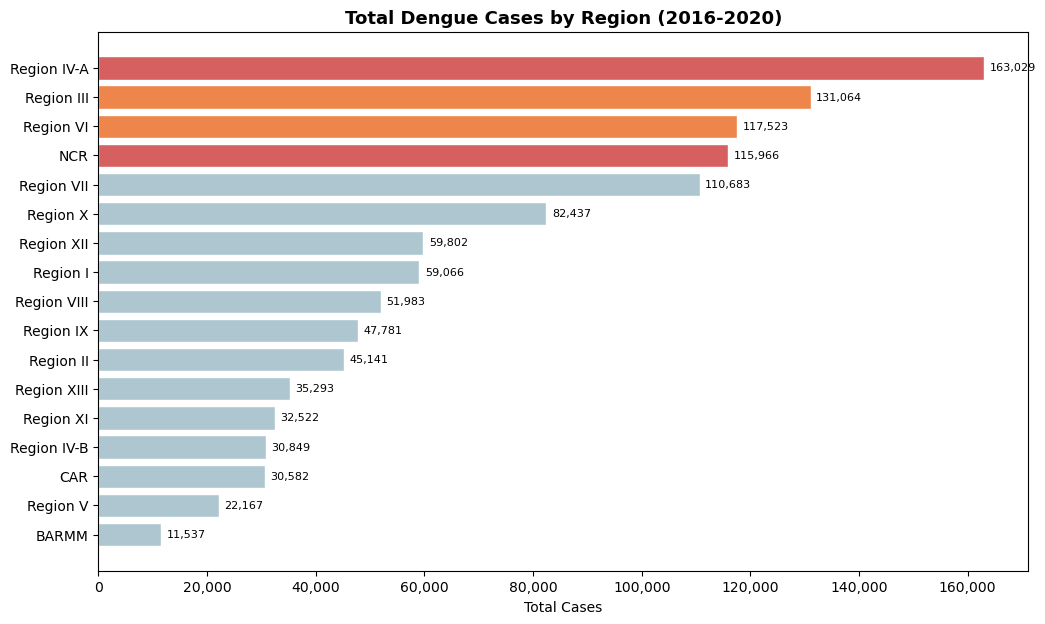

Top three regions with the highest dengue cases
         Region  Dengue_Cases  Rank
16  Region IV-A        163029     1
15   Region III        131064     2
14    Region VI        117523     3

Region IV-A: 163,029 cases (Rank #1)
NCR:         115,966 cases (Rank #4)
IV-A is 1.4x higher than NCR


In [45]:
regional = df.groupby('Region')['Dengue_Cases'].sum().sort_values(ascending=True).reset_index()
regional['Rank'] = range(len(regional), 0, -1)

colors_bar = [sns.color_palette('muted')[3] if r in ['Region IV-A','NCR'] else (sns.color_palette('muted')[1] if i > 13  else '#aec6cf')
              for i, r in enumerate(regional['Region'])]

fig, ax = plt.subplots(figsize= (12, 7))
bars = ax.barh(regional['Region'], regional['Dengue_Cases'], color=colors_bar, edgecolor='white')
ax.set_title('Total Dengue Cases by Region (2016-2020)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Cases')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _:f'{x:,.0f}'))
for bar, val in zip(bars, regional['Dengue_Cases']):
    ax.text(val + 1000, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=8)

plt.show()

# Direct comparison
print('Top three regions with the highest dengue cases')
print(regional[::-1].head(3))
print()
iva = regional[regional['Region']=='Region IV-A']['Dengue_Cases'].values[0]
ncr = regional[regional['Region']=='NCR']['Dengue_Cases'].values[0]
iva_rank = regional[regional['Region']=='Region IV-A']['Rank'].values[0]
ncr_rank = regional[regional['Region']=='NCR']['Rank'].values[0]
print(f"Region IV-A: {iva:,} cases (Rank #{iva_rank})")
print(f"NCR:         {ncr:,} cases (Rank #{ncr_rank})")
print(f"IV-A is {iva/ncr:.1f}x higher than NCR")


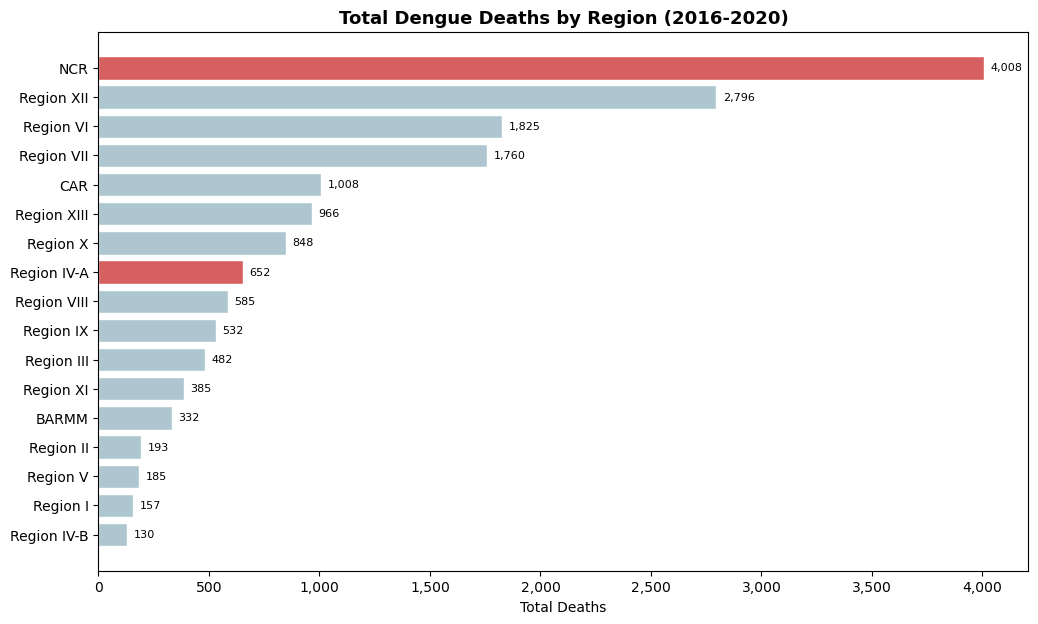

In [46]:
regional = df.groupby('Region')['Dengue_Deaths'].sum().sort_values(ascending=True).reset_index()
regional['Rank'] = range(len(regional), 0, -1)

colors_bar = [sns.color_palette('muted')[3] if r in ['Region IV-A','NCR'] else '#aec6cf'
              for i, r in enumerate(regional['Region'])]

fig, ax = plt.subplots(figsize= (12, 7))
bars = ax.barh(regional['Region'], regional['Dengue_Deaths'], color=colors_bar, edgecolor='white')
ax.set_title('Total Dengue Deaths by Region (2016-2020)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Deaths')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _:f'{x:,.0f}'))
for bar, val in zip(bars, regional['Dengue_Deaths']):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=8)

plt.show()

#### Q3. Are there specific years where dengue cases "migrated" or intensified in certain regions while staying low in others (e.g., comparing the intensity in Region VI vs. Region I)?
From 2016 to 2017, NCR doubled its cases from 13,002 to 26,103 while most other regions stayed flat or declined. It suggests that the 2017 surge was concentrated in NCR rather than a nationwide phenomenon. Region III and Region II also grew but only modestly by around 5,000 and 1,400 cases respectively.

From 2018 to 2019, all regions increased except Region II, and seven regions more than doubled their total cases. This confirms that 2019 was a nationwide outbreak of exceptional scale.

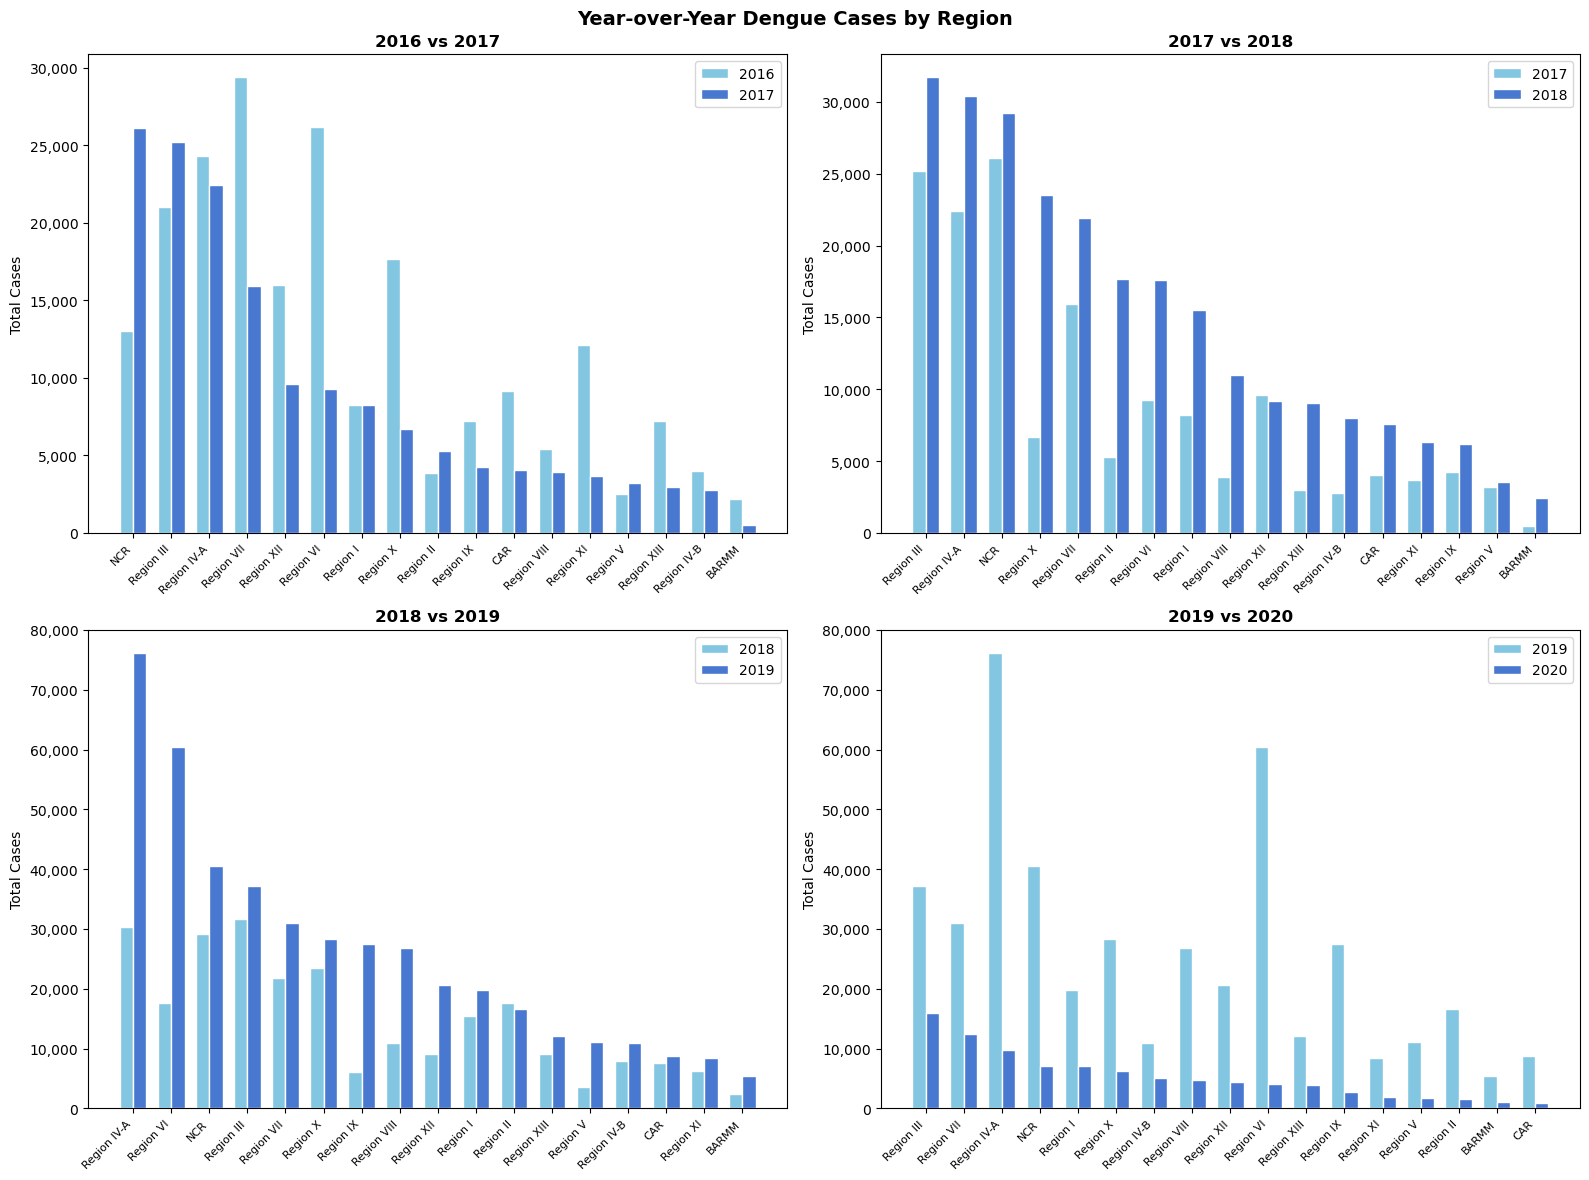

In [47]:
pivot = df.groupby(['Region', 'Year'])['Dengue_Cases'].sum().unstack()
year_pairs = [(2016, 2017), (2017, 2018), (2018, 2019), (2019, 2020)]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
width = 0.35

for idx, (y1, y2) in enumerate(year_pairs):
    data = pivot[[y1, y2]].sort_values(y2, ascending=False)
    x = range(len(data))

    axes[idx].bar([i - width/2 for i in x], data[y1], width, label=str(y1), color=sns.color_palette('muted')[9], edgecolor='white')
    axes[idx].bar([i + width/2 for i in x], data[y2], width, label=str(y2), color=sns.color_palette('muted')[0], edgecolor='white')
    axes[idx].set_xticks(list(x))
    axes[idx].set_xticklabels(data.index, rotation=45, ha='right', fontsize=8)
    axes[idx].set_title(f'{y1} vs {y2}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Total Cases')
    axes[idx].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    axes[idx].legend()

plt.suptitle('Year-over-Year Dengue Cases by Region', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Q4. Does a higher number of recorded cases in a region always correlate with a higher number of deaths, or are there "outlier" months where deaths were disproportionately high despite lower case counts?
At the monthly level, the unaggregated data shows that cases and deaths have a near-zero correlation of 0.038, which means higher case counts have no linear relationship with higher death counts. At the same time, the data shows extreme and seemingly impossible Case Fatality Rates — reaching as high as 173% in some months. This means recorded deaths exceeded recorded cases in the same month, which is biologically impossible. These apparent outliers are most likely caused by reporting lag. For instance, a patient infected in January may not die until October, so the death gets recorded in a different month than the case, distorting the monthly figures.

When the data is aggregated by month across all years, the extreme values largely disappear, supporting the reporting lag explanation. The CFR settles into a more realistic range with only minor outliers remaining.

At the regional level, the most honest picture emerges. Higher case counts do not reliably correlate with higher deaths. From the previous question, Region IV-A, despite recording the most cases nationwide, has one of the lowest fatality rates. Meanwhile, Region XII and NCR show consistently higher fatality rates despite lower case volumes, suggesting that regional factors such as healthcare access, treatment quality, and case severity play a far greater role in determining outcomes than raw case count alone.

In [48]:
df['CFR'] = (df['Dengue_Deaths'] / df['Dengue_Cases'].replace(0, pd.NA)) * 100

Correlation coefficient: 0.03832
Q1: 0.21%  Q3: 0.76%  IQR: 0.55%
Outlier threshold: 1.58%
There are 84 outlier(s) out of 1020.
Top 5 High-CFR Outliers (Grouped per Month)
  Month  Year      Region  Dengue_Cases  Dengue_Deaths        CFR
October  2016 Region XIII           277            481 173.646209
October  2017 Region VIII           144            236 163.888889
October  2017   Region IX           108            176 162.962963
October  2016         NCR          1033           1651 159.825750
October  2020         NCR           129            185 143.410853


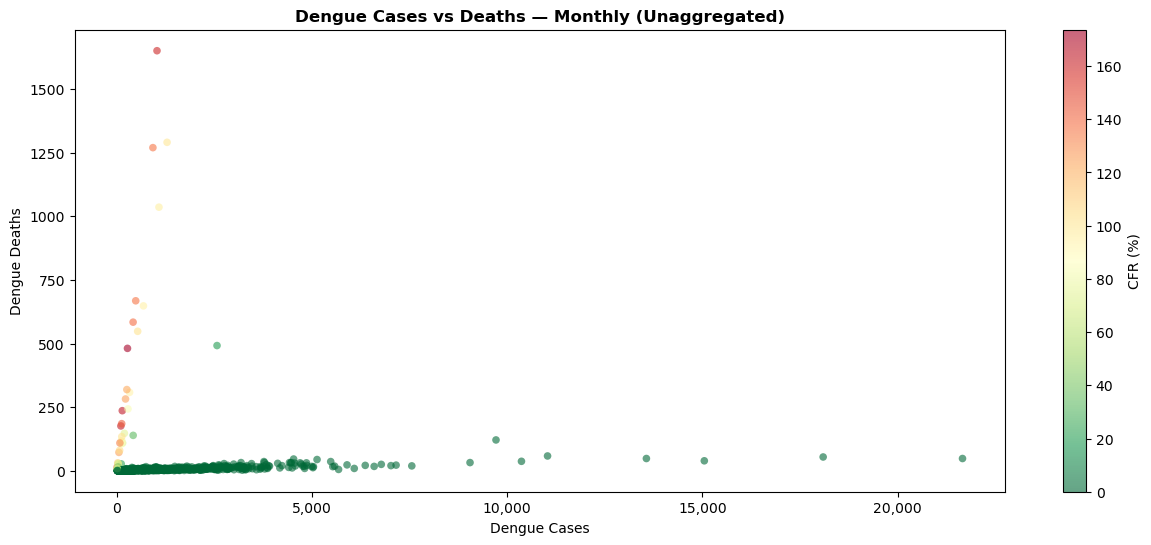

In [49]:
# Scatter: cases vs deaths with CFR as color
fig, ax = plt.subplots(figsize=(15, 6))

# Scatterplot: cases vs deaths
sc = ax.scatter(df['Dengue_Cases'], df['Dengue_Deaths'],
                     c=df['CFR'], cmap='RdYlGn_r', alpha=0.6, s=30, edgecolors='none')
plt.colorbar(sc, ax=ax, label='CFR (%)')
ax.set_title('Dengue Cases vs Deaths — Monthly (Unaggregated)', fontsize=12, fontweight='bold')
ax.set_xlabel('Dengue Cases'); ax.set_ylabel('Dengue Deaths')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Outlier: high CFR despite low cases
Q1 = df['CFR'].quantile(0.25)
Q3 = df['CFR'].quantile(0.75)
IQR = Q3 - Q1
threshold = Q3 + 1.5 * IQR

outliers = df[df['CFR'] > threshold][
    ['Month','Year','Region','Dengue_Cases','Dengue_Deaths','CFR']]
coefficient = df['Dengue_Cases'].corr(df['Dengue_Deaths'])
print(f'Correlation coefficient: {coefficient.round(5)}')
print(f"Q1: {Q1:.2f}%  Q3: {Q3:.2f}%  IQR: {IQR:.2f}%")
print(f"Outlier threshold: {threshold:.2f}%")
print(f'There are {len(outliers)} outlier(s) out of {len(df)}.')
print("Top 5 High-CFR Outliers (Grouped per Month)")
print(outliers.nlargest(5, 'CFR').to_string(index=False))

plt.show()


Q1: 0.46%  Q3: 0.63%  IQR: 0.17%
Outlier threshold: 0.89%
There are 2 outlier(s).
    Month  Dengue_Deaths  Dengue_Cases  CFR
  October           6670        117645 5.67
September           6148        177943 3.46


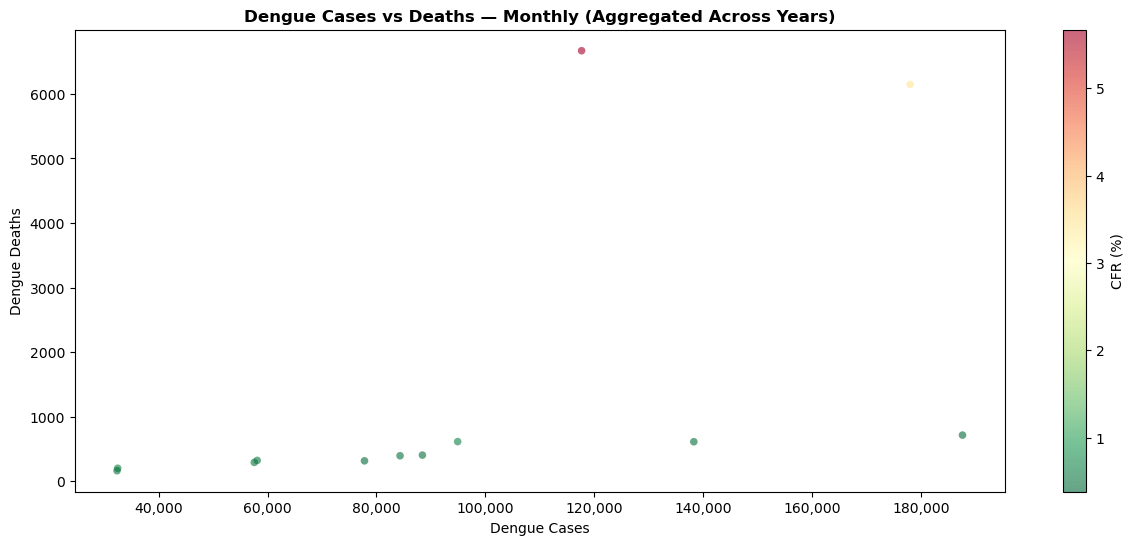

In [50]:
monthly_cfr = df.groupby('Month')[['Dengue_Deaths', 'Dengue_Cases']].sum()
monthly_cfr['CFR'] = ((monthly_cfr['Dengue_Deaths'] / monthly_cfr['Dengue_Cases']) * 100).round(2)
monthly_cfr = monthly_cfr.reset_index()

Q1 = monthly_cfr['CFR'].quantile(0.25)
Q3 = monthly_cfr['CFR'].quantile(0.75)
IQR = Q3 - Q1
threshold = Q3 + 1.5 * IQR
outliers = monthly_cfr[monthly_cfr['CFR'] > threshold]
print(f"Q1: {Q1:.2f}%  Q3: {Q3:.2f}%  IQR: {IQR:.2f}%")
print(f"Outlier threshold: {threshold:.2f}%")
print(f'There are {len(outliers)} outlier(s).')
print(outliers.nlargest(5, 'CFR').to_string(index=False))


fig, ax = plt.subplots(figsize=(15, 6))

# Scatterplot: cases vs deaths
sc = ax.scatter(monthly_cfr['Dengue_Cases'], monthly_cfr['Dengue_Deaths'],
                     c=monthly_cfr['CFR'], cmap='RdYlGn_r', alpha=0.6, s=30, edgecolors='none')
plt.colorbar(sc, ax=ax, label='CFR (%)')
ax.set_title('Dengue Cases vs Deaths — Monthly (Aggregated Across Years)', fontsize=12, fontweight='bold')
ax.set_xlabel('Dengue Cases'); ax.set_ylabel('Dengue Deaths')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

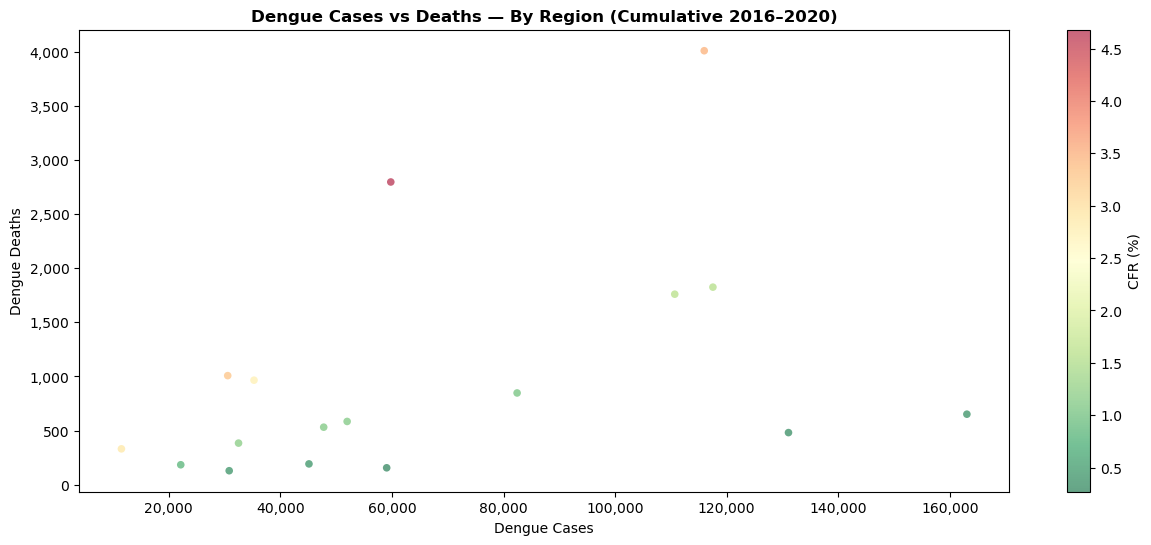

In [51]:
# Using regional CFR instead
regional_cfr = df.groupby('Region')[['Dengue_Cases','Dengue_Deaths']].sum()
regional_cfr['CFR'] = ((regional_cfr['Dengue_Deaths'] / regional_cfr['Dengue_Cases']) * 100).round(2)
regional_cfr = regional_cfr.reset_index()

fig, ax = plt.subplots( figsize=(15, 6))

# scatter cases vs deaths
sc = ax.scatter(regional_cfr['Dengue_Cases'], regional_cfr['Dengue_Deaths'],
                     c=regional_cfr['CFR'], cmap='RdYlGn_r', alpha=0.6, s=30, edgecolors='none')
plt.colorbar(sc, ax=ax, label='CFR (%)')
ax.set_title('Dengue Cases vs Deaths — By Region (Cumulative 2016–2020)', fontsize=12, fontweight='bold')
ax.set_xlabel('Dengue Cases'); ax.set_ylabel('Dengue Deaths')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.show()

Q1: 0.43%  Q3: 2.74%  IQR: 2.31%
Outlier threshold: 6.21%
There are 0 outlier(s).


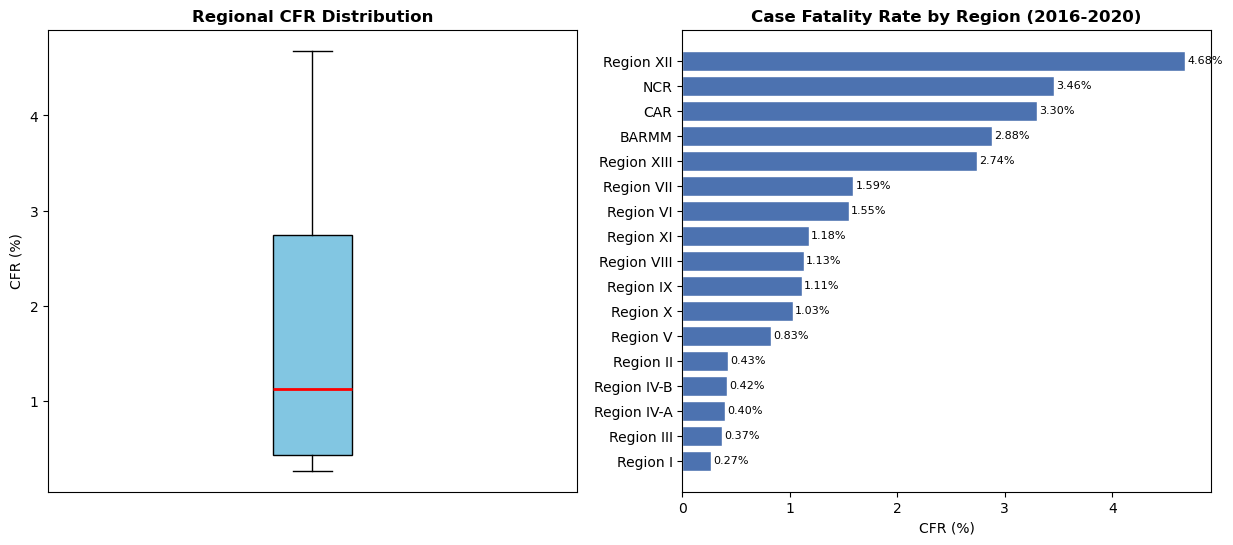

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: box plot of regional CFR
axes[0].boxplot(regional_cfr['CFR'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=sns.color_palette('muted')[9]),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markersize=6, alpha=0.7))
axes[0].set_title('Regional CFR Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('CFR (%)')
axes[0].set_xticks([])

Q1 = regional_cfr['CFR'].quantile(0.25)
Q3 = regional_cfr['CFR'].quantile(0.75)
IQR = Q3 - Q1
threshold = Q3 + 1.5 * IQR
outliers = regional_cfr[regional_cfr['CFR'] > threshold]
print(f"Q1: {Q1:.2f}%  Q3: {Q3:.2f}%  IQR: {IQR:.2f}%")
print(f"Outlier threshold: {threshold:.2f}%")
print(f'There are {len(outliers)} outlier(s).')

# Right: horizontal bar of regional CFR sorted
regional_cfr_sorted = regional_cfr.sort_values('CFR', ascending=True)
bars = axes[1].barh(regional_cfr_sorted['Region'], regional_cfr_sorted['CFR'],
                    color=sns.color_palette('deep')[0], edgecolor='white')
axes[1].set_title('Case Fatality Rate by Region (2016-2020)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('CFR (%)')
for bar, val in zip(bars, regional_cfr_sorted['CFR']):
    axes[1].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}%', va='center', fontsize=8)

plt.show()


#### Q5. In the year 2019 (the peak year), what percentage of the total national dengue cases was contributed by the top five most affected regions combined?
The top 5 regions in 2019 are Region IV-A, Region VI, NCR, Region III, and Region VII. They contributed **55.50%** of all national cases combined.

Total national cases in 2019: 441,902
Top 5 regions combined:       245,241
Percentage of Top 5 regions:  55.50%

Top 5 Regions in 2019
  Region IV-A       76,195 cases  (17.24%)
  Region VI         60,357 cases  (13.66%)
  NCR               40,478 cases  (9.16%)
  Region III        37,158 cases  (8.41%)
  Region VII        31,053 cases  (7.03%)


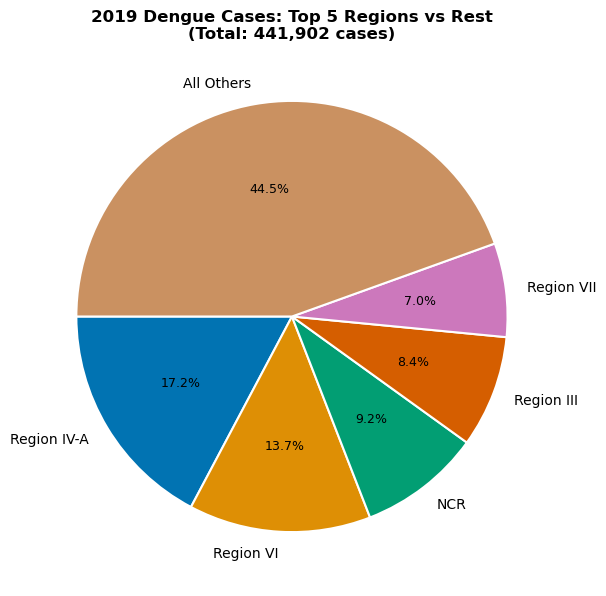

In [53]:
cases_2019 = df[df['Year'] == 2019].groupby('Region')['Dengue_Cases'].sum().sort_values(ascending=False)
total_2019 = cases_2019.sum()
top5_2019 = cases_2019.head(5)
top5_total = top5_2019.sum()
top5_pct = (top5_total / total_2019) * 100

print(f"Total national cases in 2019: {total_2019:,}")
print(f"Top 5 regions combined:       {top5_total:,}")
print(f"Percentage of Top 5 regions:  {top5_pct:.2f}%")
print()
print("Top 5 Regions in 2019")
for region, cases in top5_2019.items():
    pct = cases / total_2019 * 100
    print(f"  {region:<15} {cases:>8,} cases  ({pct:.2f}%)")

# Pie chart
others = total_2019 - top5_total
labels = list(top5_2019.index) + ['All Others']
sizes = list(top5_2019.values) + [others]
colors_pie = sns.color_palette('colorblind', 6)

fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=colors_pie, startangle=180,
    wedgeprops={'edgecolor':'white','linewidth':1.5},
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title(f'2019 Dengue Cases: Top 5 Regions vs Rest\n(Total: {total_2019:,} cases)',
             fontsize=12, fontweight='bold')
plt.show()


### Findings and Insights (Conclusion)
- Peak dengue season is July to October, with August recording the highest cases across all years.
- 2019 was an exceptional outbreak year with 441,902 total cases — nearly double 2018 and five times 2020.
- The three highest-burden regions are Region IV-A (163,029), Region III (131,064), and Region VI (117,523).
- Case count does not equal death count. NCR leads in deaths with a 3.46% fatality rate while Region IV-A, despite the most cases, has only a 0.40% fatality rate. Region XII has the highest fatality rate at 4.68%.
- From 2016 to 2017, the surge was concentrated in NCR, which doubled its cases while most regions stayed flat. From 2018 to 2019, the outbreak became nationwide — every region increased except Region II, and seven regions more than doubled.
- The top 5 regions contributed 55.5% of all 2019 national cases — Region IV-A, Region VI, NCR, Region III, and Region VII.
- Monthly CFR figures are unreliable due to reporting lag, producing impossible fatality rates as high as 173%. Regional aggregates are the more honest measure.

#### Conclusion
The 2016–2020 dengue data shows a clear seasonal pattern peaking between July and October, with 2019 standing out as an unusually severe year that affected every region in the country. High case counts do not always lead to high deaths. Some regions recorded far more fatalities despite having fewer cases, suggesting that factors other than case volume, such as healthcare access and treatment quality, play a significant role in survival outcomes.

Key Questions:(Please answer these questions using your data visualization)
1.  Which specific months across the 2016-2020 period represent the peak "Dengue Season" in the Philippines, and was the 2019 outbreak significantly higher than other years?
2. Between 2016 and 2020, which three regions consistently recorded the highest volume of dengue cases, and how does Region IV-A compare to the National Capital Region (NCR)?
3. Are there specific years where dengue cases "migrated" or intensified in certain regions while staying low in others (e.g., comparing the intensity in Region VI vs. Region I)?
4. Does a higher number of recorded cases in a region always correlate with a higher number of deaths, or are there "outlier" months where deaths were disproportionately high despite lower case counts?
5. In the year 2019 (the peak year), what percentage of the total national dengue cases was contributed by the top five most affected regions combined?